# Distribution Planning Benchmark

Goal: test whether the policy transports a population distribution toward a target law while paying only the movement cost needed to do so.

**Environment Basics**

- State space: $\mathcal{X}=\{0,\ldots,n_x-1\}$, arranged on a ring.
- Action space: three actions encoded as `{0, 1, 2}` and mapped to moves $\{-1,0,+1\}$ modulo $n_x$.
- Population law: $\mu_t$ is a probability vector over ring sites; $\mu_\star$ is the target distribution.
- Dynamics: choosing move $a\in\{-1,0,+1\}$ sends state $x$ to $(x+a)\bmod n_x$.
- Main task: match $\mu_\star$ while limiting unnecessary movement around the ring.

The ring dynamics use actions $a\in\{-1,0,+1\}$ and the reward decomposes as

$$
r(x,a,\mu)=-\|\mu-\mu_\star\|_2^2-\lambda_{move}|a|,
\qquad
J(\theta)=\sum_{t=0}^{T} \mathbb{E}_{\mu_t,\pi_\theta}[r(X_t,A_t,\mu_t)].
$$

The diagnostic plots therefore focus on the state-time heatmap, target errors $\|\mu_t-\mu_\star\|_1$, $\|\mu_t-\mu_\star\|_2$, a ring $W_1$ proxy, and transport flux.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "distribution-planning"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "mid"
RUN_MISSING = True
FORCE_REBUILD = False
EXTENDED = True

In [2]:
bundle = (
    nh.ensure_discrete_benchmark_bundle(ENV_NAME, BASE_DIR, quick=QUICK, force=FORCE_REBUILD, extended=EXTENDED, preset=PRESET)
    if RUN_MISSING
    else nh.bundle_paths(ENV_NAME, BASE_DIR)
)
bundle

{'env': 'distribution-planning',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/distribution-planning'),
 'train': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/distribution-planning/train/distribution-planning_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/distribution-planning/train/distribution-planning_logits')},
 'application': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/distribution-planning/application/distribution-planning_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/distribution-planning/application/distribution-planning_logits')},
 'diagnostics': {'simplex': {'perturbation': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/distribution-planning/diagnostics/distribution-planning_simplex_perturbation'),
   'functional_law': PosixPath

## Figure Coverage

Goal: show which requested results from `docs/figures.md` are currently produced by this notebook and which artifacts support them.

The tables are an audit layer, not an estimator. A row maps a desired result family to the command or study that generates its data and to the notebook helper that renders it.

In [3]:
nh.figure_checklist(ENV_NAME)

,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [4]:
nh.figure_coverage_matrix(ENV_NAME)

,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Training: Simplex vs Logits

Goal: compare the optimization traces of the two finite-state perturbation geometries.

The value/objective plot estimates $J(\theta_k)$ at training episode $k$. The gradient plot tracks $\|\widehat g_k\|_2$, where $\widehat g_k$ is the MF-REINFORCE gradient estimate used by Adam.

Simplex uses affine law perturbations on the simplex; logits uses logistic-normal perturbations in logit coordinates. The curves should be compared using the same saved train/evaluation budget.

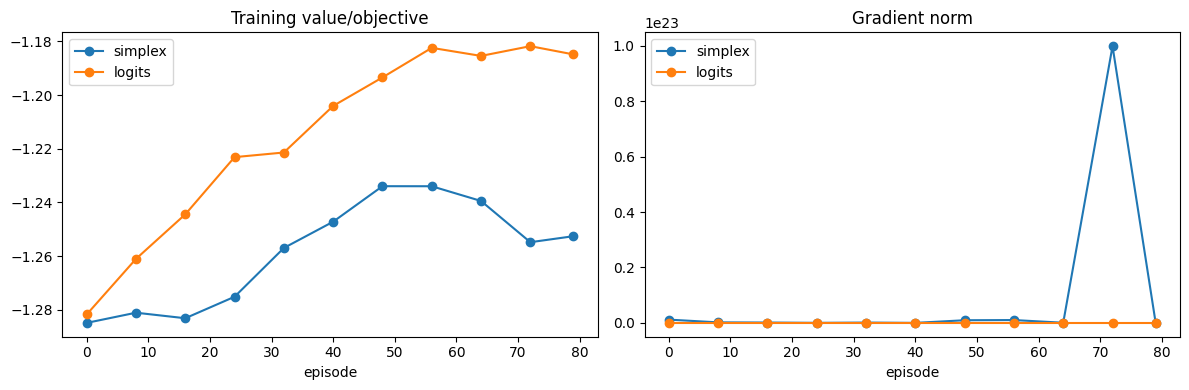

In [5]:
histories = nh.load_training_histories(bundle)
nh.plot_training_comparison(histories)

## Application Diagnostics

Goal: inspect whether the policy moves mass toward the target distribution with controlled transport.

Reference: the second heatmap row and dashed metric curves use a model-based exact-flow policy optimized by differentiating the finite-state population recursion. This gives a strong numerical reference for target-tracking behavior.

The heatmap shows $\mu_t(x)$ over state and time. The error curves track

$$
\|\mu_t-\mu_\star\|_1,
\qquad
\|\mu_t-\mu_\star\|_2,
\qquad
W_1(\mu_t,\mu_\star)\ \text{(ring proxy)}.
$$

The flux panel summarizes how much mass is transported around the ring at each time.

,algorithm,reference_kind,learned_value,reference_value,reference_value_gap
0,simplex,model_based_exact_flow_reference,-1.252574,-0.139307,1.113268
1,logits,model_based_exact_flow_reference,-1.184855,-0.139307,1.045549


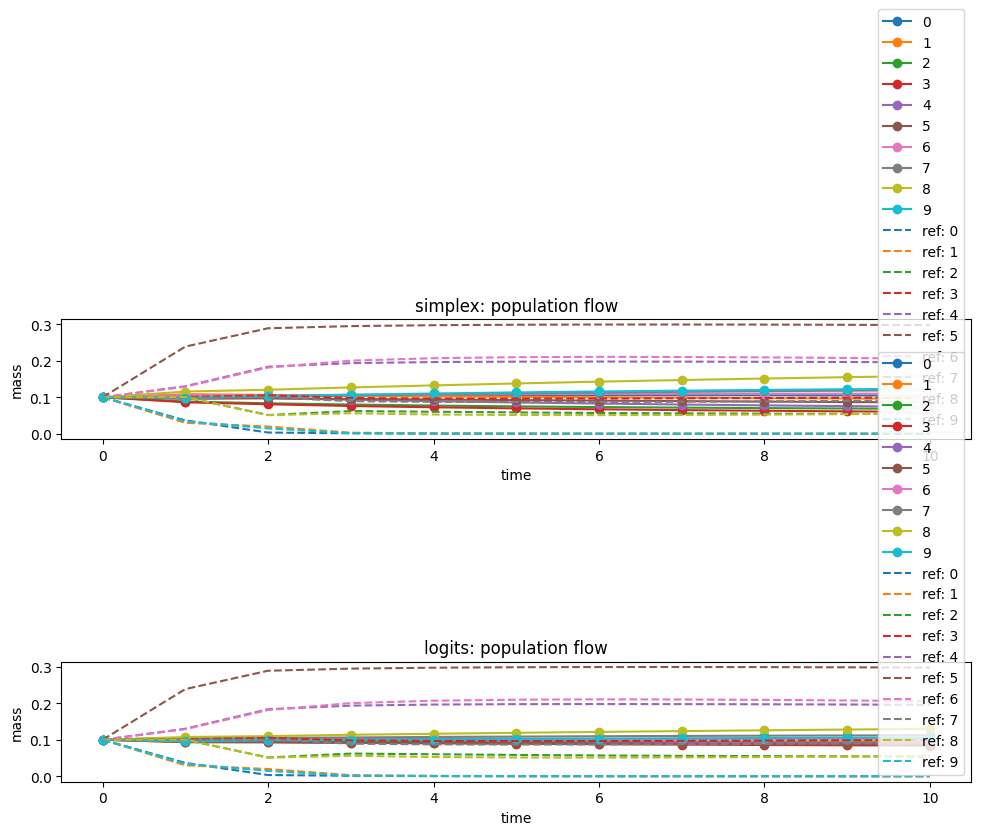

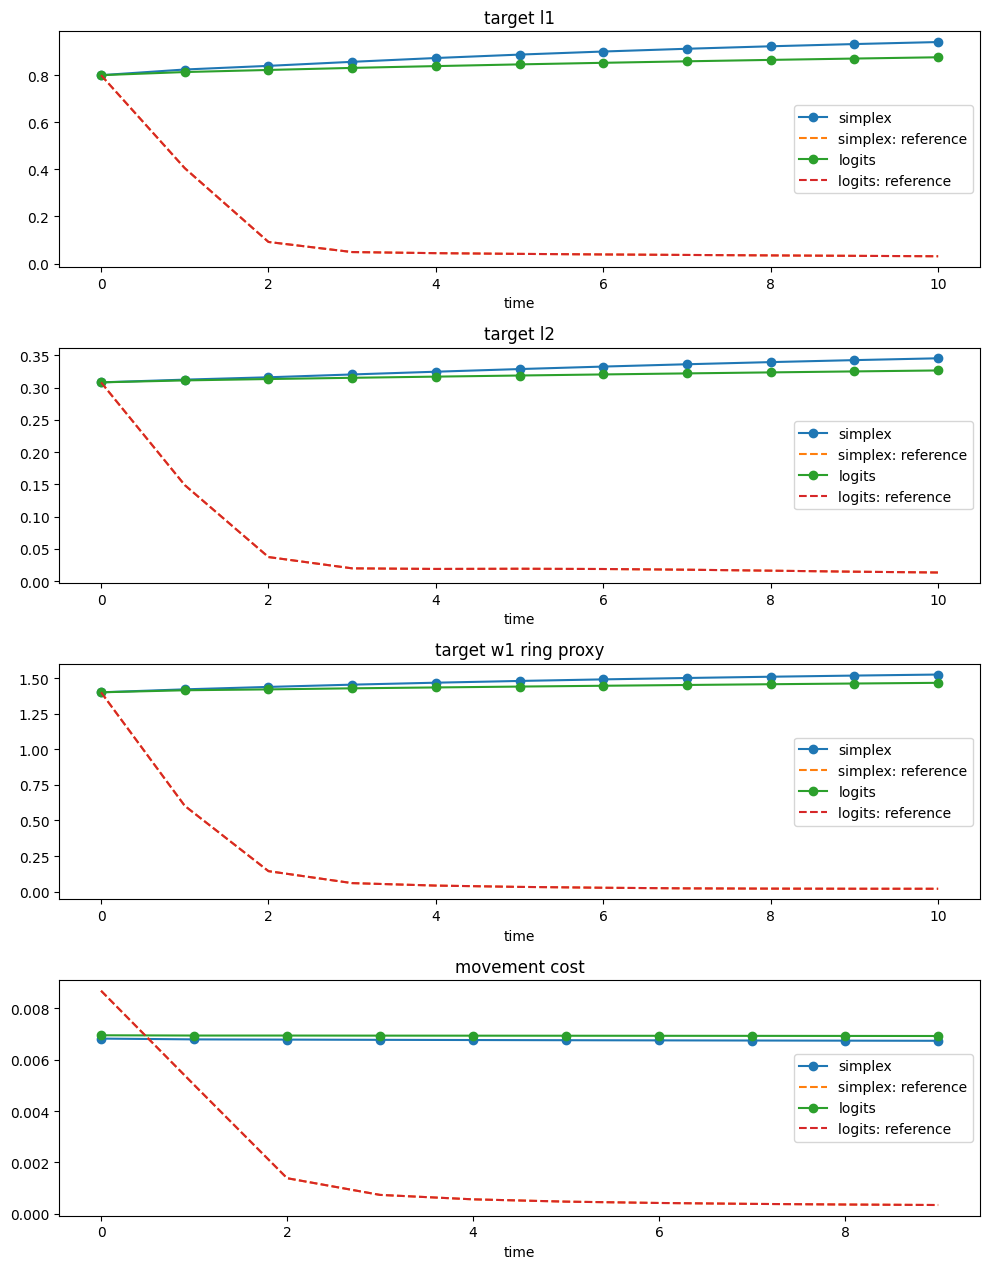

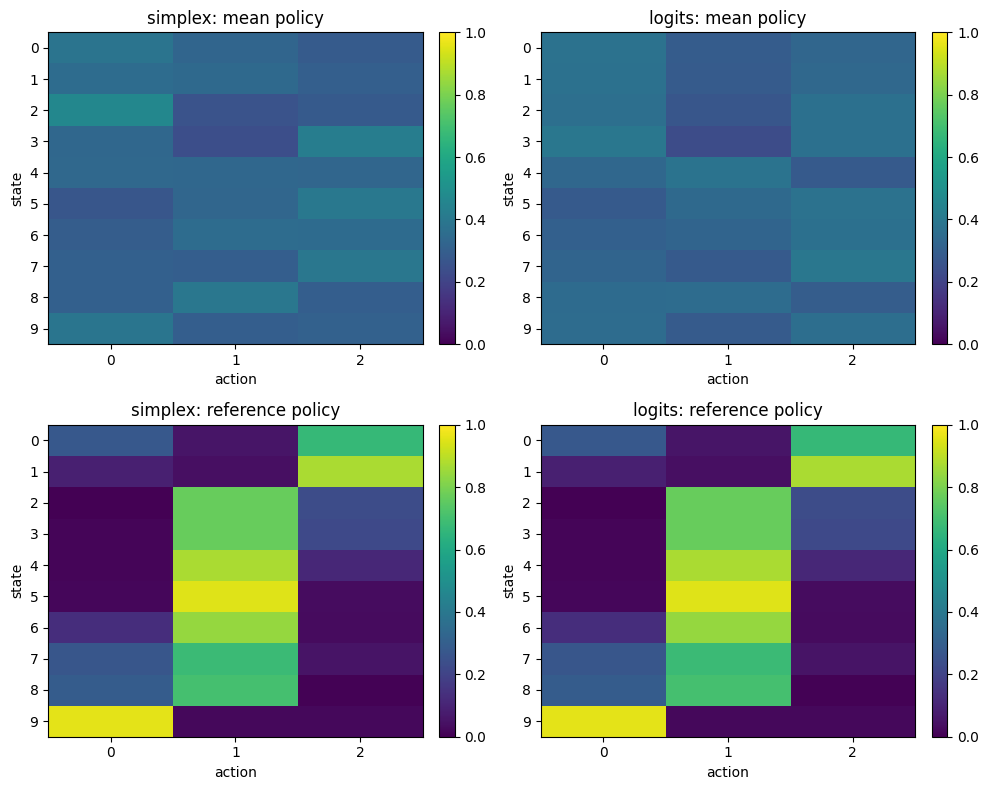

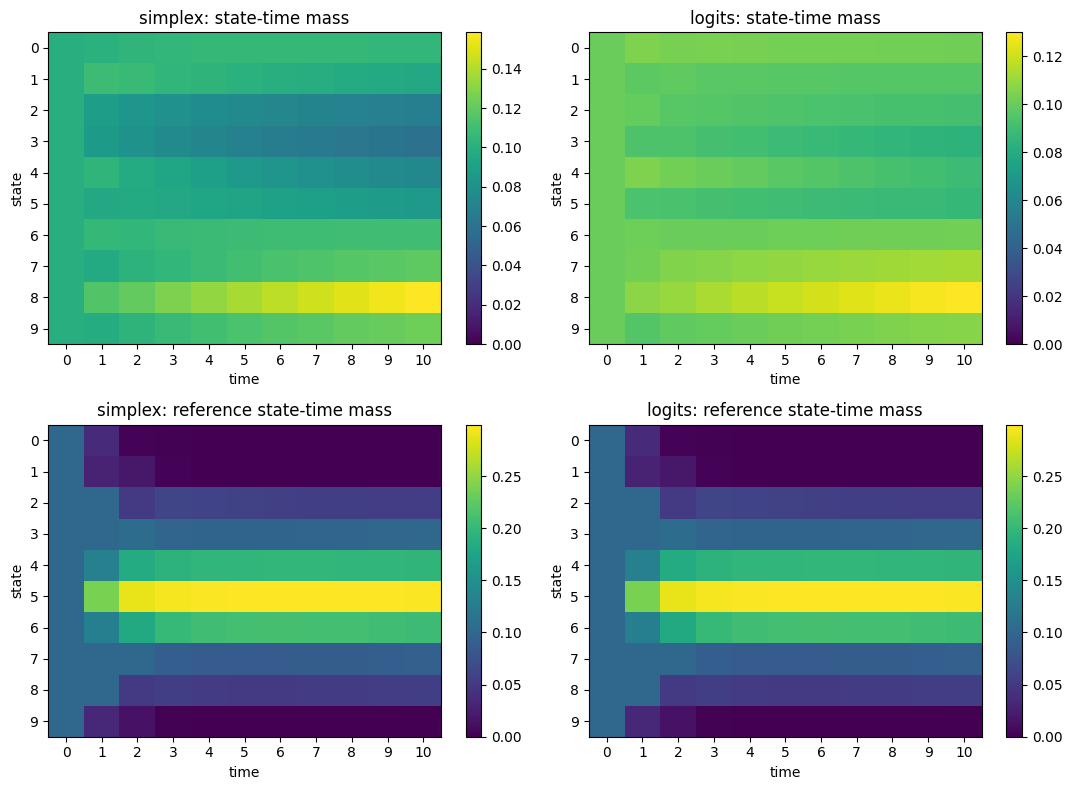

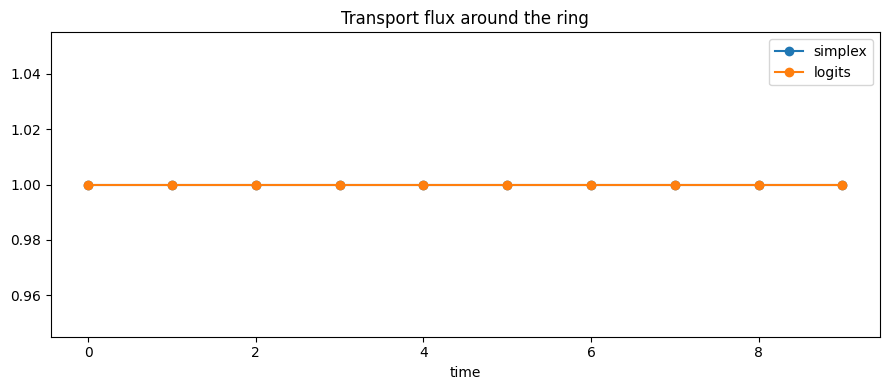

In [6]:
application = nh.load_application_data(bundle)
display(nh.reference_solution_table(ENV_NAME, application))
nh.plot_population_flow(application, ENV_NAME)
nh.plot_time_metrics(application, ENV_NAME)
nh.plot_policy_heatmaps(application, ENV_NAME)
nh.plot_discrete_application_details(application, ENV_NAME)

## Universal Diagnostics

Goal: validate the estimator chain before interpreting optimization performance.

The perturbation plots measure empirical geometry,

$$
d(M^\lambda,\mu),
$$

including quantile bands and local log-log slopes. The functional-law plots study

$$
\Gamma(M^\lambda)=(F_1(M^\lambda),\ldots,F_k(M^\lambda)),
\qquad
\frac{\Gamma(M^\lambda)-\Gamma(\mu)}{\lambda},
$$

which is the induced law of population signatures. The score plots check

$$
S_{t,\lambda}^\theta=\nabla_\theta\log q_{t,\lambda}^\theta(M_t),
\qquad \mathbb{E}[S_{t,\lambda}^\theta]\approx 0,
$$

and the gradient plots report bias, variance, MSE, norm ratio, and cosine agreement for an estimator $\widehat g$ against an oracle or reference gradient $g$:

$$
\operatorname{MSE}=\mathbb{E}\|\widehat g-g\|_2^2,
\qquad
\cos(\widehat g,g)=\frac{\widehat g\cdot g}{\|\widehat g\|_2\|g\|_2}.
$$

The sensitivity plots track errors in $D_t=\partial_\theta\Gamma(\mu_t^\theta)$, or in the finite-state case $D_t=\partial_\theta\mu_t^\theta$.

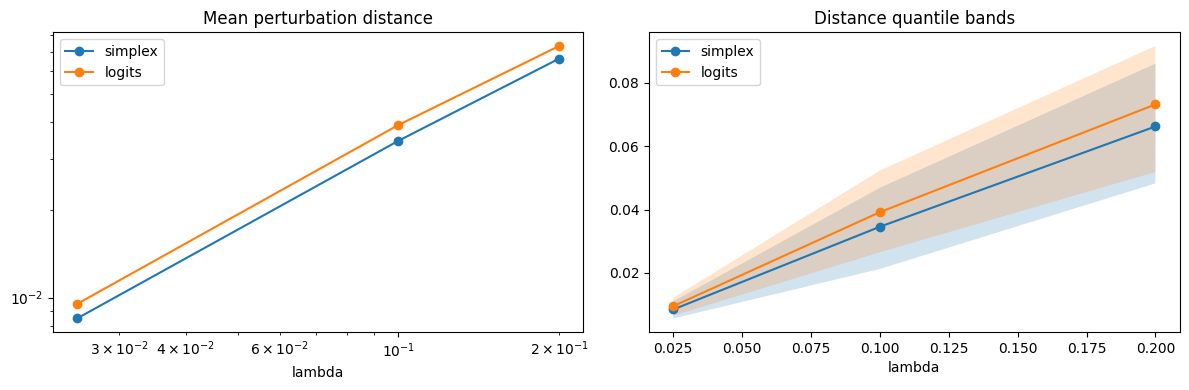

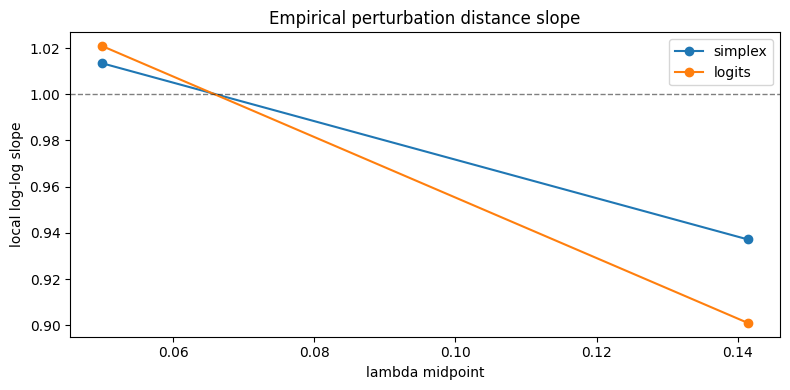

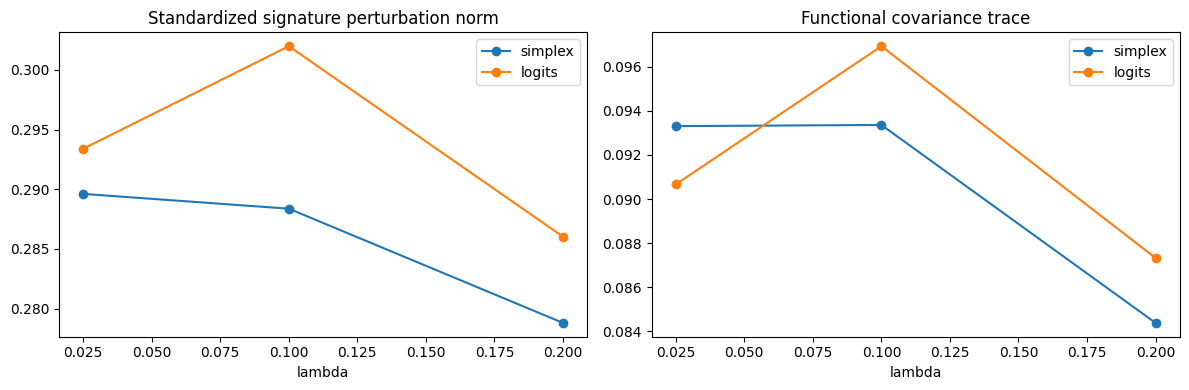

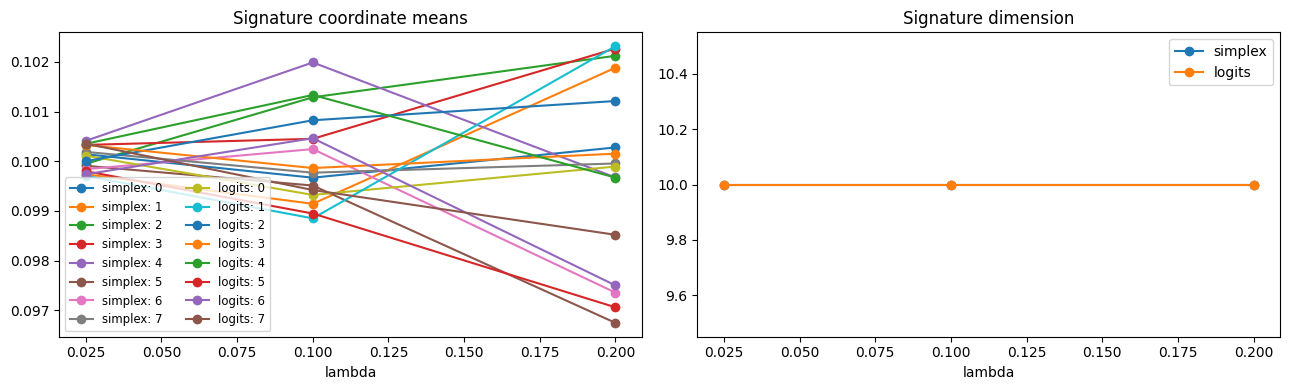

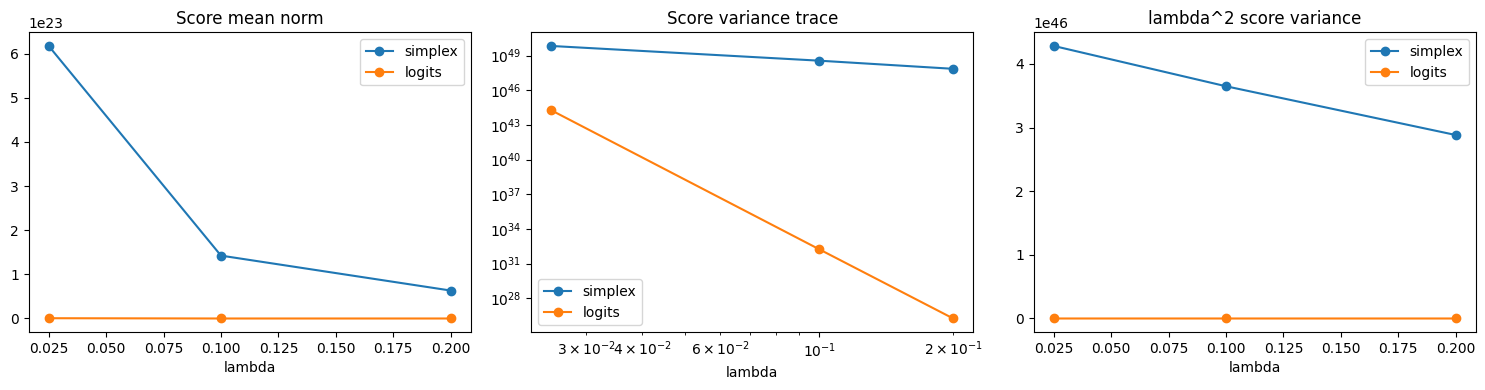

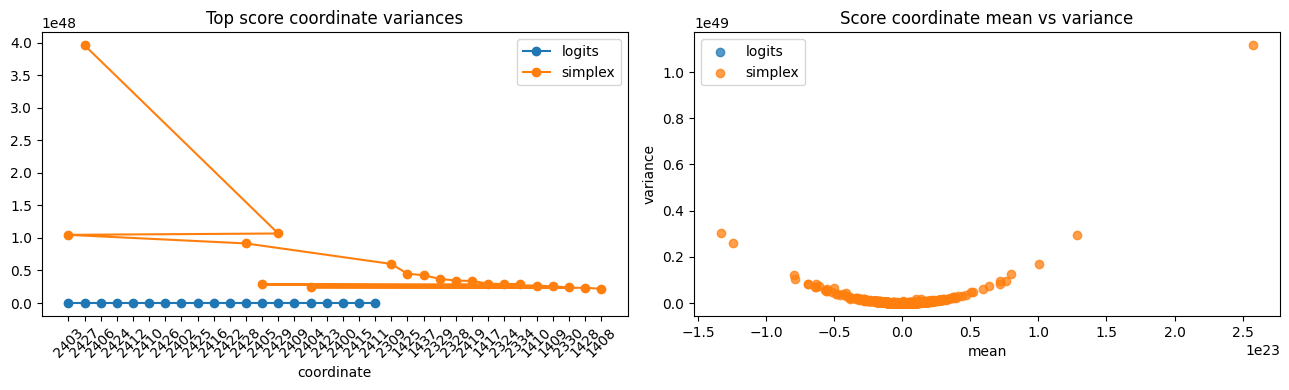

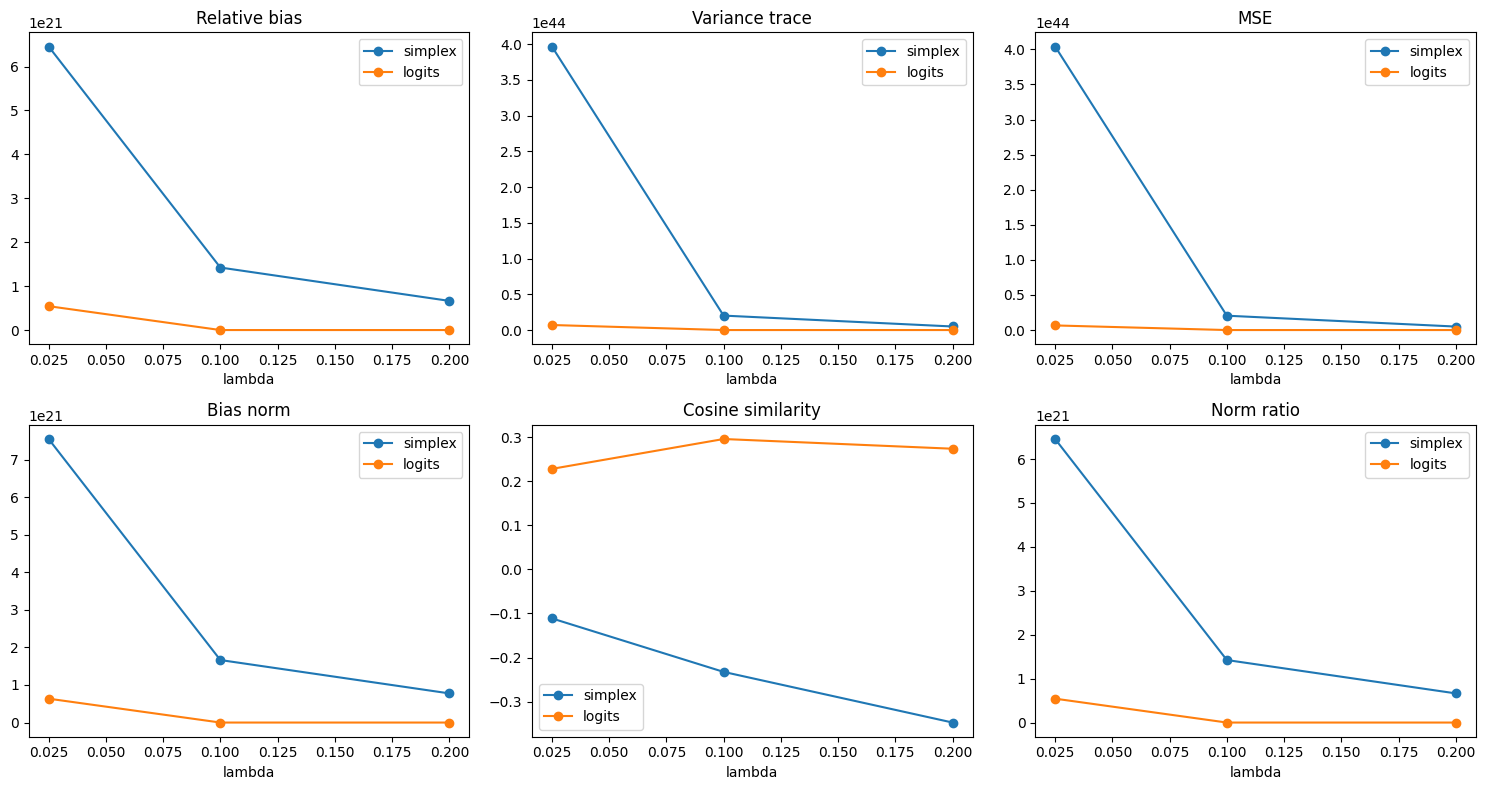

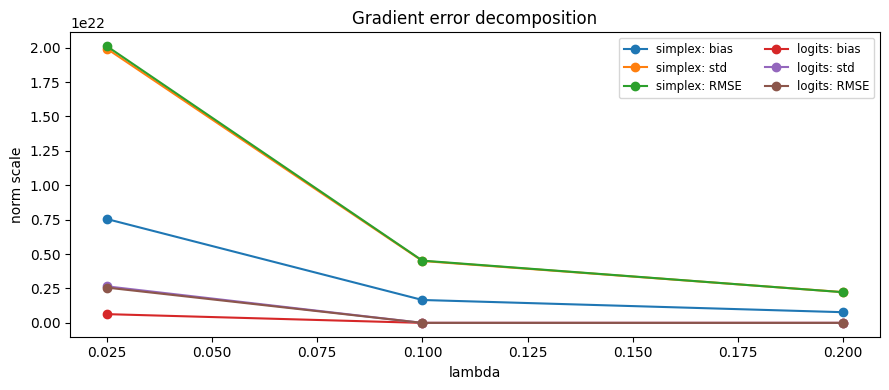

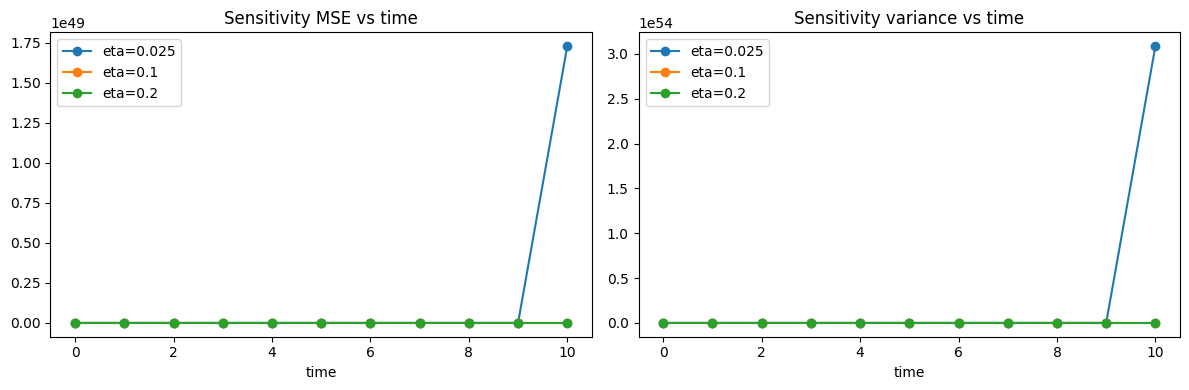

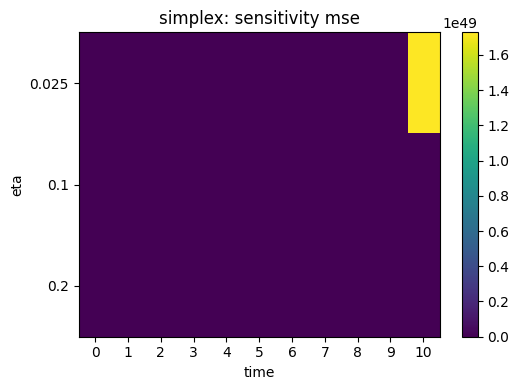

In [7]:
diagnostics = nh.load_diagnostic_data(bundle)
nh.plot_perturbation_geometry(diagnostics)
nh.plot_perturbation_slopes(diagnostics)
nh.plot_functional_law(diagnostics)
nh.plot_functional_signature_means(diagnostics)
nh.plot_score_validation(diagnostics)
nh.plot_score_coordinate_diagnostics(diagnostics)
nh.plot_gradient_validation(diagnostics)
nh.plot_gradient_error_decomposition(diagnostics)
nh.plot_sensitivity_validation(diagnostics)
nh.plot_sensitivity_heatmap(diagnostics)

## Scaling, Budget, And Optimization Summaries

Goal: measure how estimator quality and optimization performance change with simulator budget, auxiliary budget, horizon, and training time.

The budget heatmap varies main and auxiliary samples $(B,n)$ under the approximate cost model

$$
C\approx C_{main}B+C_{aux}n.
$$

The horizon plot studies how gradient error changes with $T$, and the optimization plots compare objective or cost gaps against iteration count, runtime, and simulator-call budget.

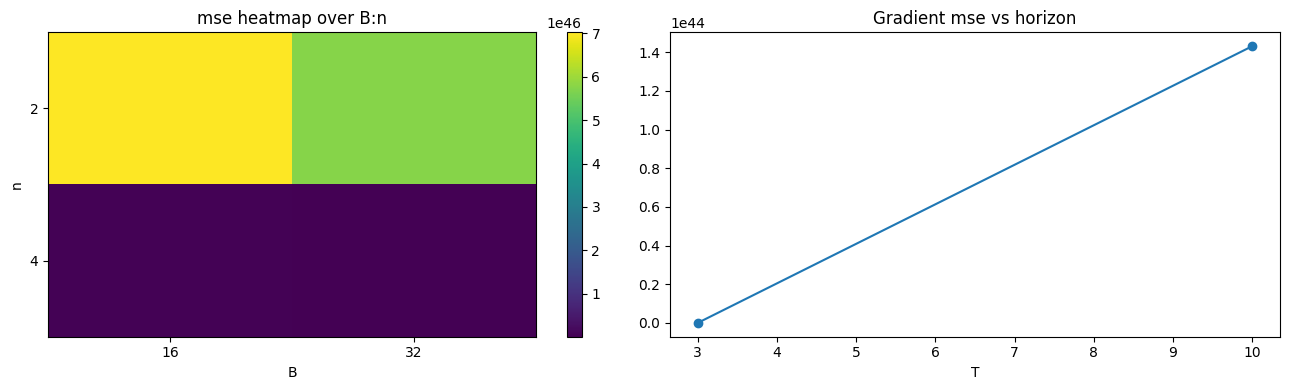

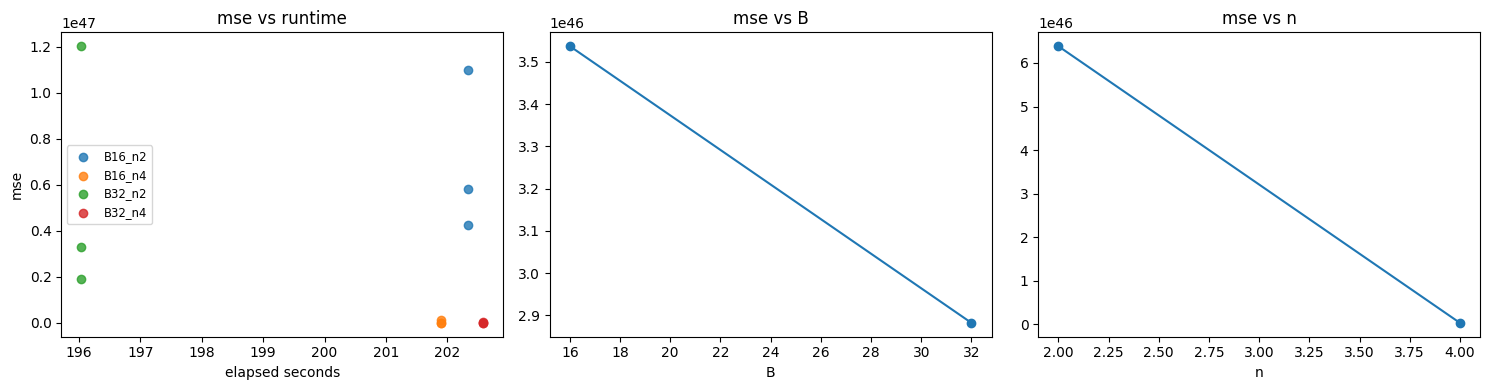

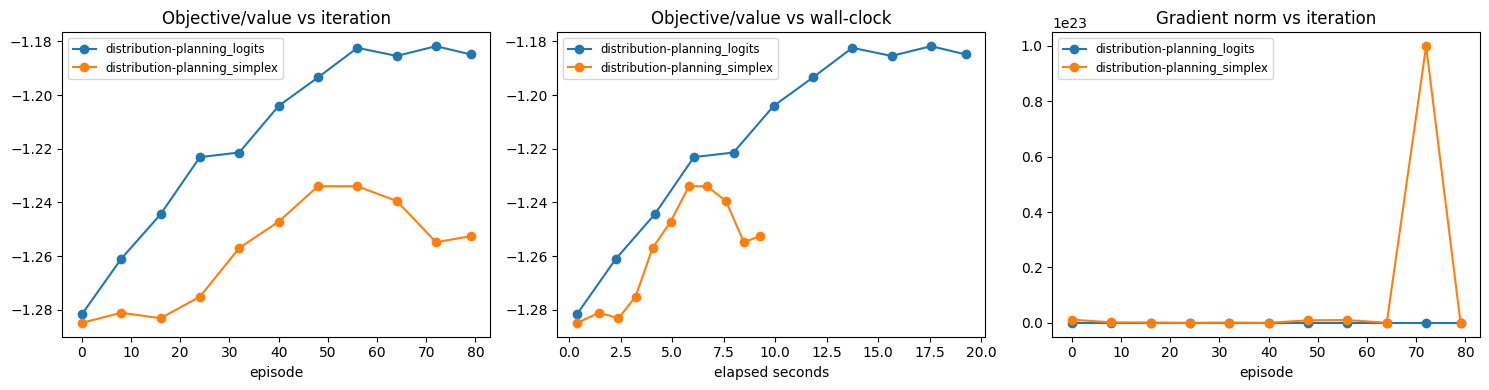

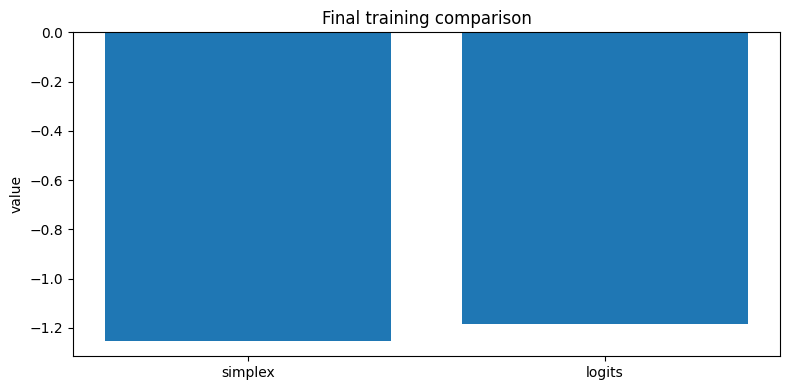

In [8]:
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
optimization_history = nh.load_optimization_history(bundle)
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)

## Raw Tables For Custom Figures

Goal: expose the underlying CSV/JSON artifacts used by the plots so paper figures can be restyled or recomputed without rerunning training.

These tables are not new estimators. They are the saved values for population flows, policies, diagnostics, study grids, histories, and final metrics.

In [9]:
application["simplex"]["time_metrics"].head(), diagnostics["simplex"]["gradient"].head(), studies["budget"].head()

(                     env  law_index  time  target_l1  target_l2  \
 0  distribution-planning          0     0   0.800000   0.308221   
 1  distribution-planning          0     1   0.824060   0.312446   
 2  distribution-planning          0     2   0.839563   0.316102   
 3  distribution-planning          0     3   0.856682   0.320485   
 4  distribution-planning          0     4   0.872860   0.324746   
 
    target_w1_ring_proxy  movement_cost  
 0              1.400000       0.006825  
 1              1.420836       0.006794  
 2              1.437828       0.006786  
 3              1.453752       0.006777  
 4              1.467501       0.006769  ,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8   7.545497e+21    3.968080e+44   
 1   0.100             8   1.663514e+21    2.021490e+43   
 2   0.200             8   7.757993e+20    4.988178e+42   
 
    covariance_largest_eigenvalue  oracle_norm     bias_norm  relative_bias  \
 0                  